# Arabic Word Recognition — My Own Dataset
### CNN (character classifier) + YOLOv8 (character detector)
#### Dataset: my own handwritten words labelled in Label Studio

## 1. Install & Import Libraries

In [1]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow Pillow tqdm seaborn

In [2]:
import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.21.0
GPU available: False


## 2. Paths & Class Setup

In [3]:
# ── Project root ─────────────────────────────────────────────
ROOT         = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN")
MY_DATASET   = ROOT / "my_dataset"       # exported from Label Studio
AHAWP_DIR    = ROOT / "isolated_alphabets_per_alphabet"  # for CNN training

YOLO_DATASET = ROOT / "my_dataset"       # already has train/ and val/ structure
IMG_SIZE     = 64

# Verify paths exist
for p in [MY_DATASET, AHAWP_DIR]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet


In [4]:
# ── Read class names directly from Label Studio export ───────
# Label Studio YOLO export puts class names in classes.txt
classes_file = MY_DATASET / "classes.txt"

if classes_file.exists():
    ARABIC_LABELS = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
    print("Loaded classes from classes.txt")
else:
    # Derive from label files if classes.txt is missing
    label_files = list((MY_DATASET / "train" / "labels").glob("*.txt"))
    class_ids = set()
    for f in label_files:
        for line in f.read_text().splitlines():
            if line.strip():
                class_ids.add(int(line.split()[0]))
    # Build label list from AHAWP folder names as fallback
    FORM_MAP = {'begin':'beginning','middle':'middle','end':'end',
                'regular':'isolated','hamza':'hamza','alif':'alif'}
    all_labels = []
    for sub in sorted(AHAWP_DIR.iterdir()):
        if not sub.is_dir(): continue
        parts = sub.name.rsplit('_', 1)
        if len(parts) != 2: continue
        letter, form_raw = parts
        form = FORM_MAP.get(form_raw)
        if form: all_labels.append(f"{letter}_{form}")
    ARABIC_LABELS = sorted(set(all_labels))
    print("Derived classes from AHAWP folder names")

NUM_CLASSES = len(ARABIC_LABELS)
print(f"\nTotal classes: {NUM_CLASSES}")
print(f"Classes: {ARABIC_LABELS}")

# Save for inference use later
np.save("label_classes.npy", np.array(ARABIC_LABELS))

Loaded classes from classes.txt

Total classes: 105
Classes: ['ain_begin', 'ain_end', 'ain_middle', 'ain_regular', 'alif_end', 'alif_hamza', 'alif_regular', 'beh_begin', 'beh_end', 'beh_middle', 'beh_regular', 'dad_begin', 'dad_end', 'dad_middle', 'dad_regular', 'dal_end', 'dal_regular', 'feh_begin', 'feh_end', 'feh_middle', 'feh_regular', 'ghain_begin', 'ghain_end', 'ghain_middle', 'ghain_regular', 'hah_begin', 'hah_end', 'hah_middle', 'hah_regular', 'hamza', 'heh_begin', 'heh_end', 'heh_middle', 'heh_regular', 'jeem_begin', 'jeem_end', 'jeem_middle', 'jeem_regular', 'kaf_begin', 'kaf_end', 'kaf_middle', 'kaf_regular', 'khah_begin', 'khah_end', 'khah_middle', 'khah_regular', 'lam_alif', 'lam_begin', 'lam_end', 'lam_middle', 'lam_regular', 'meem_begin', 'meem_end', 'meem_middle', 'meem_regular', 'noon_begin', 'noon_end', 'noon_middle', 'noon_regular', 'qaf_begin', 'qaf_end', 'qaf_middle', 'qaf_regular', 'raa_end', 'raa_regular', 'sad_begin', 'sad_end', 'sad_middle', 'sad_regular', 'see

## 3. CNN Training — Character Classifier
Uses `isolated_alphabets_per_alphabet` (AHAWP) for training since it has many examples per character form.

In [5]:
FORM_MAP = {
    'begin':   'beginning',
    'middle':  'middle',
    'end':     'end',
    'regular': 'isolated',
    'hamza':   'hamza',
    'alif':    'alif',
}

def load_isolated_dataset(alphabets_dir: Path, img_size: int = IMG_SIZE):
    images, labels = [], []
    valid = set(ARABIC_LABELS)

    for subfolder in sorted(alphabets_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        parts = subfolder.name.rsplit('_', 1)
        if len(parts) != 2:
            continue
        letter, form_raw = parts
        form = FORM_MAP.get(form_raw)
        if form is None:
            continue
        label = f"{letter}_{form}"
        if label not in valid:
            continue  # skip classes not in our label set

        for img_path in sorted(subfolder.glob("*.png")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)

    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    y = np.array(labels)
    print(f"Loaded {len(X)} images across {len(set(labels))} classes")
    return X, y


X_all, y_all = load_isolated_dataset(AHAWP_DIR)

le = LabelEncoder()
le.fit(ARABIC_LABELS)
y_encoded = le.transform(y_all)
np.save("label_classes.npy", le.classes_)
print(f"y_encoded shape: {y_encoded.shape}")

Loaded 27840 images across 34 classes
y_encoded shape: (27840,)


In [12]:
# Update ARABIC_LABELS to only what was actually found in the data
ARABIC_LABELS = list(le.classes_)
NUM_CLASSES   = len(ARABIC_LABELS)
print(f"Actual classes used: {NUM_CLASSES}")
print(ARABIC_LABELS)

Actual classes used: 105
[np.str_('ain_begin'), np.str_('ain_end'), np.str_('ain_middle'), np.str_('ain_regular'), np.str_('alif_end'), np.str_('alif_hamza'), np.str_('alif_regular'), np.str_('beh_begin'), np.str_('beh_end'), np.str_('beh_middle'), np.str_('beh_regular'), np.str_('dad_begin'), np.str_('dad_end'), np.str_('dad_middle'), np.str_('dad_regular'), np.str_('dal_end'), np.str_('dal_regular'), np.str_('feh_begin'), np.str_('feh_end'), np.str_('feh_middle'), np.str_('feh_regular'), np.str_('ghain_begin'), np.str_('ghain_end'), np.str_('ghain_middle'), np.str_('ghain_regular'), np.str_('hah_begin'), np.str_('hah_end'), np.str_('hah_middle'), np.str_('hah_regular'), np.str_('hamza'), np.str_('heh_begin'), np.str_('heh_end'), np.str_('heh_middle'), np.str_('heh_regular'), np.str_('jeem_begin'), np.str_('jeem_end'), np.str_('jeem_middle'), np.str_('jeem_regular'), np.str_('kaf_begin'), np.str_('kaf_end'), np.str_('kaf_middle'), np.str_('kaf_regular'), np.str_('khah_begin'), np.str_

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.30, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

def expand_channel(X):
    return np.concatenate([X, X, X], axis=-1)

X_train_3ch = expand_channel(X_train)
X_val_3ch   = expand_channel(X_val)
X_test_3ch  = expand_channel(X_test)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (19488, 64, 64, 1)  Val: (4176, 64, 64, 1)  Test: (4176, 64, 64, 1)


In [14]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)

def build_mobilenet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inp = Input(shape=input_shape)
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out, name='MobileNetV2_Arabic')
    return model, base

model, base_model = build_mobilenet_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_arabic_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

model.summary()

C:\Users\hagar\AppData\Local\Temp\ipykernel_16912\1189536824.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "MobileNetV2_Arabic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 105)            │        26,985 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,612,905 (9.97 MB)

 Trainable params: 354,921 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
print("Phase 1: Training head with frozen base...")
history_phase1 = model.fit(
    datagen.flow(X_train_3ch, y_train, batch_size=64),
    validation_data=(X_val_3ch, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training head with frozen base...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.1524 - loss: 3.3913
Epoch 1: val_accuracy improved from None to 0.41188, saving model to best_arabic_cnn.keras

Epoch 1: finished saving model to best_arabic_cnn.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.2329 - loss: 2.8602 - val_accuracy: 0.4119 - val_loss: 2.0908 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3537 - loss: 2.2380
Epoch 2: val_accuracy improved from 0.41188 to 0.46791, saving model to best_arabic_cnn.keras

Epoch 2: finished saving model to best_arabic_cnn.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.3691 - loss: 2.1668 - val_accuracy: 0.4679 - val_loss: 1.8132 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4113 - loss: 1.9998
Epoch 3: val_accuracy improved from 0.46791 to 0.48515, saving model to best_arabic_cnn.keras

Epoch 3: finishe

In [16]:
print("Phase 2: Fine-tuning top 30 layers...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    datagen.flow(X_train_3ch, y_train, batch_size=32),
    validation_data=(X_val_3ch, y_val),
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Phase 2: Fine-tuning top 30 layers...
Epoch 1/15
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1320 - loss: 5.0118
Epoch 1: val_accuracy did not improve from 0.58405
609/609 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.1575 - loss: 4.1886 - val_accuracy: 0.3379 - val_loss: 2.4888 - learning_rate: 1.0000e-05
Epoch 2/15
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2114 - loss: 3.0879
Epoch 2: val_accuracy did not improve from 0.58405
609/609 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.2244 - loss: 2.9531 - val_accuracy: 0.3355 - val_loss: 2.3513 - learning_rate: 1.0000e-05
Epoch 3/15
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2662 - loss: 2.6334
Epoch 3: val_accuracy did not improve from 0.58405
609/609 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.2788 - loss: 2.5745 - val_accuracy: 0.3877 - val_loss: 2.1109 - learning_rate: 1.0000e-05
Epoch 4/15
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3156 - loss: 2.3844
Epoch 4: ReduceLROnP

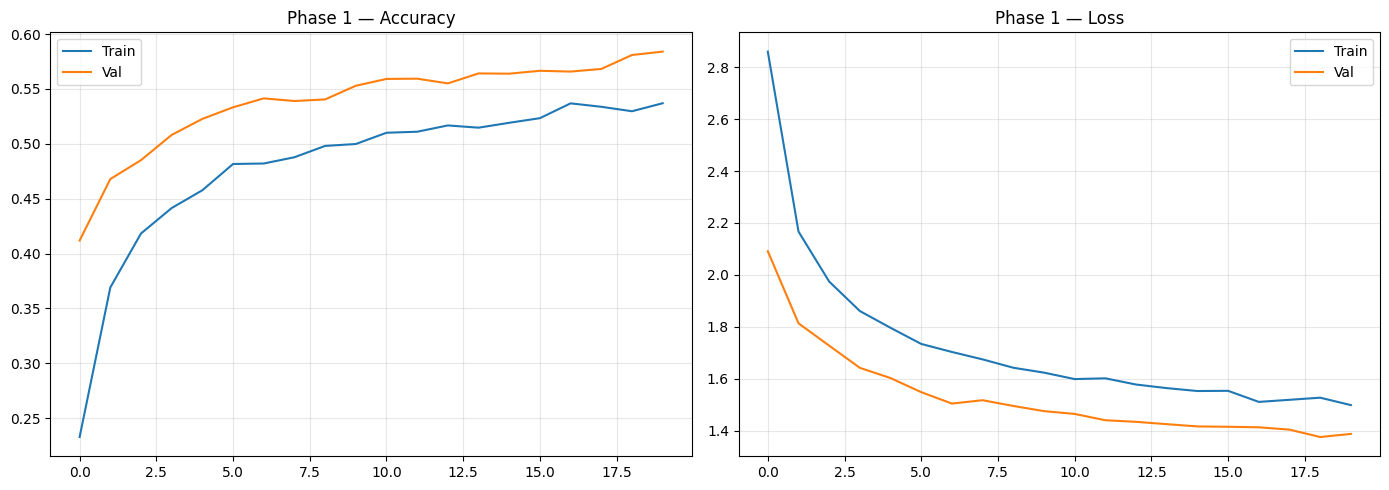

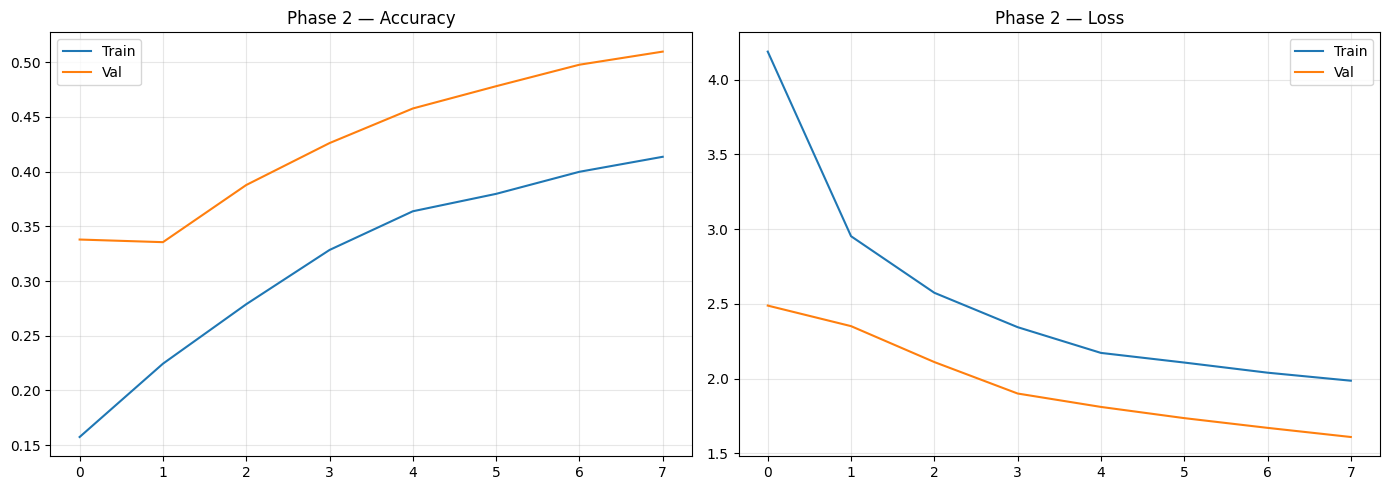

In [17]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    h = history.history
    axes[0].plot(h['accuracy'], label='Train'); axes[0].plot(h['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(h['loss'], label='Train'); axes[1].plot(h['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history_phase1, 'Phase 1')
plot_history(history_phase2, 'Phase 2')

In [21]:
loss, acc = model.evaluate(X_test_3ch, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Test Loss    : {loss:.4f}")

y_pred = np.argmax(model.predict(X_test_3ch), axis=1)

# Only report on classes that actually appear in the test set
present_classes = sorted(np.unique(np.concatenate([y_test, y_pred])))
present_names   = [ARABIC_LABELS[i] for i in present_classes]

print(classification_report(y_test, y_pred, labels=present_classes, target_names=present_names))

model.save('arabic_cnn_final.keras')
print("Saved: arabic_cnn_final.keras")

Test Accuracy: 0.3393 (33.93%)
Test Loss    : 2.5143
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
              precision    recall  f1-score   support

     ain_end       0.27      0.67      0.38       123
  ain_middle       0.21      0.38      0.27       123
    alif_end       0.65      0.33      0.43       123
  alif_hamza       0.62      0.27      0.38       123
     beh_end       0.47      0.34      0.40       123
  beh_middle       0.25      0.27      0.26       123
     dal_end       0.20      0.11      0.14       123
     feh_end       0.16      0.05      0.08       122
  feh_middle       0.11      0.12      0.12       121
     heh_end       0.27      0.20      0.23       123
  heh_middle       0.29      0.45      0.35       123
    jeem_end       0.37      0.65      0.47       123
 jeem_middle       0.42      0.22      0.29       123
     kaf_end       0.40      0.31      0.35       123
  kaf_middle       0.42      0.41      0.42       123
    lam_alif       0.54      0.57      0

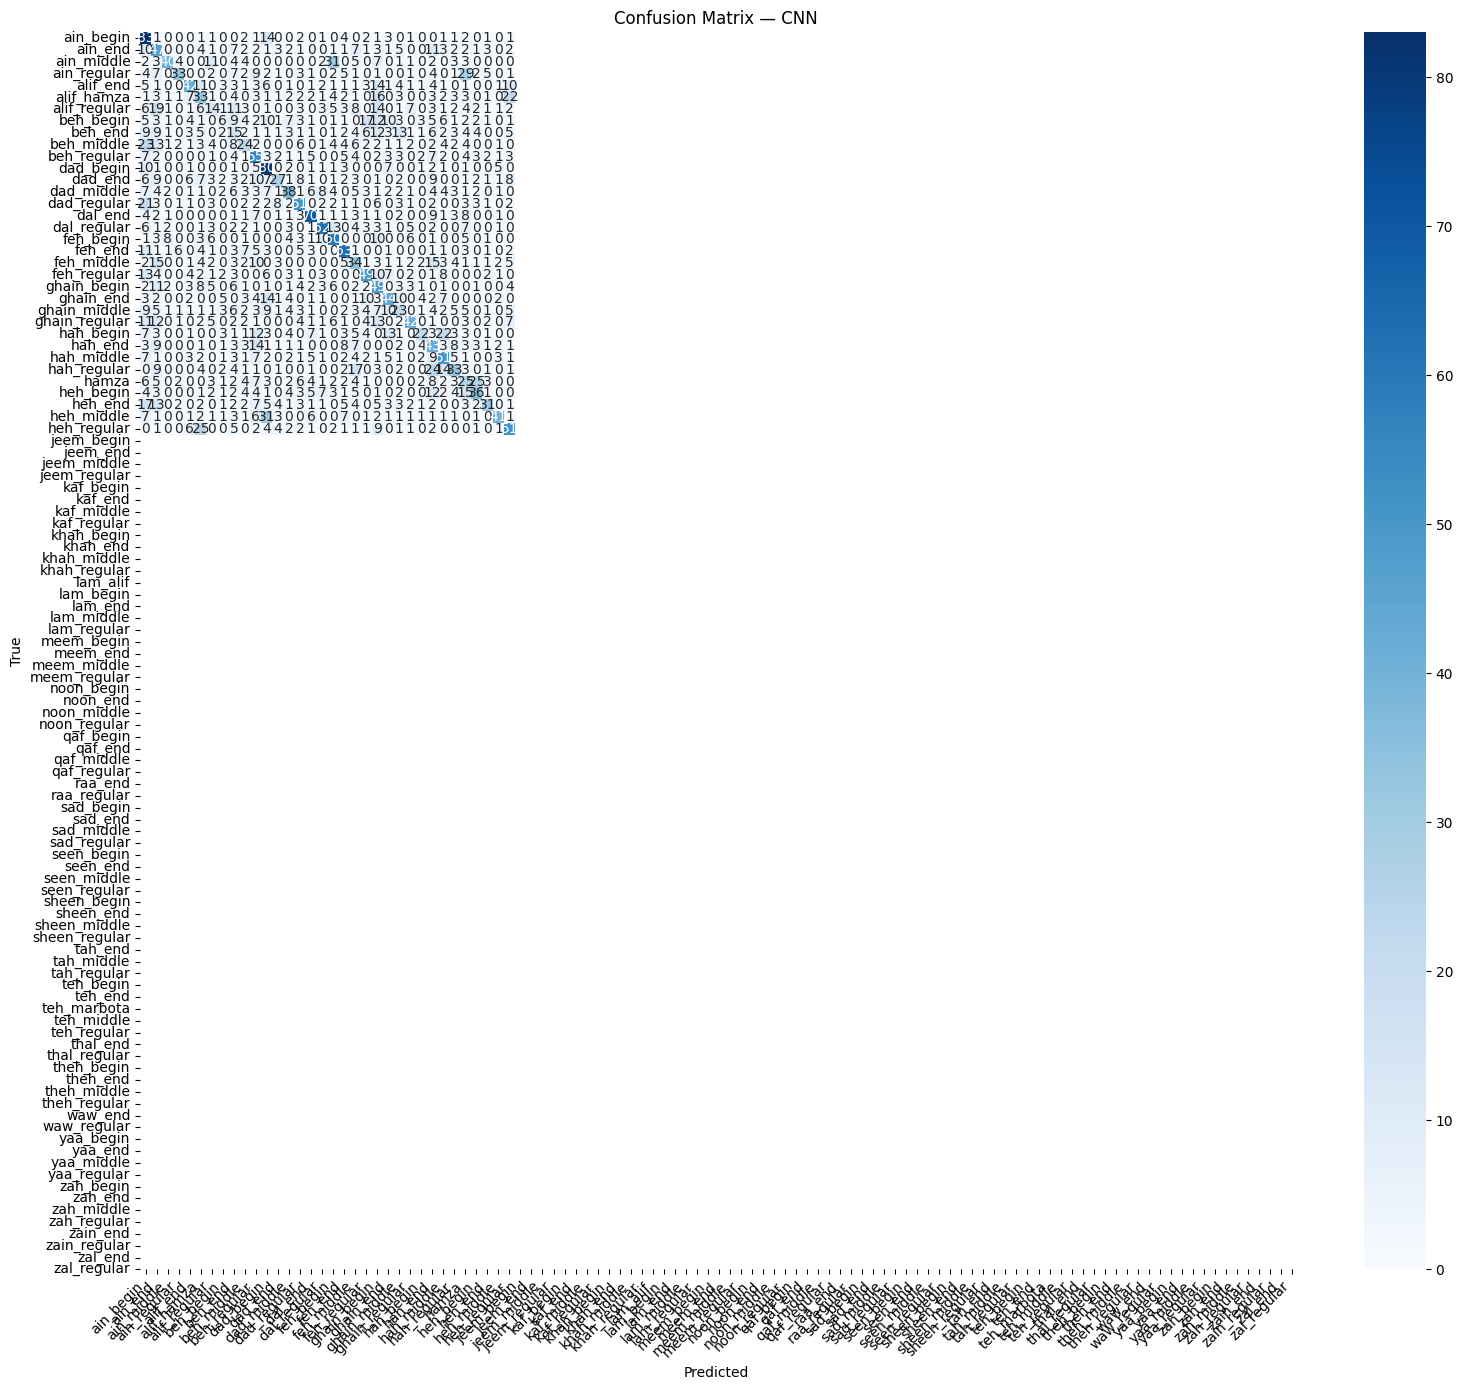

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ARABIC_LABELS, yticklabels=ARABIC_LABELS)
plt.title('Confusion Matrix — CNN')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 4. YOLO Training — Character Detector
Uses the annotated word images from `my_dataset` (exported from Label Studio).

In [32]:
# ── Verify dataset structure ─────────────────────────────────
train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
train_lbls = list((MY_DATASET / 'train' / 'labels').glob('*.txt'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
val_lbls   = list((MY_DATASET / 'val'   / 'labels').glob('*.txt'))

print(f"Train — images: {len(train_imgs)}  labels: {len(train_lbls)}")
print(f"Val   — images: {len(val_imgs)}    labels: {len(val_lbls)}")

if len(train_imgs) == 0:
    print("\nERROR: No training images found. Check MY_DATASET path.")
if len(val_imgs) == 0:
    print("\nERROR: No val images found. Move some train images to val/images.")

Train — images: 60  labels: 60
Val   — images: 13    labels: 13


In [33]:
# ── Write data.yaml ──────────────────────────────────────────
yaml_path = MY_DATASET / 'data.yaml'

with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write(f"nc: {NUM_CLASSES}\n")
    f.write("names:\n")
    for c in ARABIC_LABELS:
        f.write(f"  - {c}\n")

print(f"Saved: {yaml_path}")
print(open(yaml_path).read())

Saved: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml
path: F:/bach2/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 105
names:
  - ain_begin
  - ain_end
  - ain_middle
  - ain_regular
  - alif_end
  - alif_hamza
  - alif_regular
  - beh_begin
  - beh_end
  - beh_middle
  - beh_regular
  - dad_begin
  - dad_end
  - dad_middle
  - dad_regular
  - dal_end
  - dal_regular
  - feh_begin
  - feh_end
  - feh_middle
  - feh_regular
  - ghain_begin
  - ghain_end
  - ghain_middle
  - ghain_regular
  - hah_begin
  - hah_end
  - hah_middle
  - hah_regular
  - hamza
  - heh_begin
  - heh_end
  - heh_middle
  - heh_regular
  - jeem_begin
  - jeem_end
  - jeem_middle
  - jeem_regular
  - kaf_begin
  - kaf_end
  - kaf_middle
  - kaf_regular
  - khah_begin
  - khah_end
  - khah_middle
  - khah_regular
  - lam_alif
  - lam_begin
  - lam_end
  - lam_middle
  - lam_regular
  - meem_begin
  - meem_end
  - meem_middle

In [34]:
# ── Train YOLO ───────────────────────────────────────────────
yolo_model = YOLO('yolov8s.pt')

yolo_results = yolo_model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=4,
    patience=20,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0 if len(train_imgs) < 50 else 0.5,
    mixup=0.0  if len(train_imgs) < 50 else 0.1,
    hsv_h=0.015,
    hsv_s=0.3,
    hsv_v=0.3,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO training complete!")
print(f"Weights: {YOLO_WEIGHTS}")
print(f"Weights exist: {YOLO_WEIGHTS.exists()}")

New https://pypi.org/project/ultralytics/8.4.25 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.

## 5. Inference Pipeline

In [35]:
# ── Load models ──────────────────────────────────────────────
USE_MOBILENET = True
YOLO_WEIGHTS  = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = tf.keras.models.load_model('arabic_cnn_final.keras')
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load('label_classes.npy', allow_pickle=True)

print(f"CNN loaded")
print(f"YOLO loaded: {YOLO_WEIGHTS}")
print(f"Classes: {len(label_classes)}")

CNN loaded
YOLO loaded: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt
Classes: 105


In [36]:
def preprocess_for_cnn(crop_bgr, img_size=IMG_SIZE, use_3ch=True):
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    roi = thresh[y:y+h, x:x+w]
    side = int(max(h, w) * 1.2)
    canvas = np.zeros((side, side), dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi
    resized = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    if use_3ch:
        normalized = np.stack([normalized] * 3, axis=-1)
    else:
        normalized = normalized[..., np.newaxis]
    return normalized


def recognize_word(image_path, conf_threshold=0.3, iou_threshold=0.3):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # YOLO detection with NMS to reduce duplicate boxes
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes = results.boxes

    if len(boxes) == 0:
        print("No characters detected.")
        return [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        yolo_label = ARABIC_LABELS[int(box.cls[0])]
        yolo_conf  = float(box.conf[0])
        detections.append((x1, y1, x2, y2, yolo_label, yolo_conf))

    # Sort RTL (right-to-left)
    detections.sort(key=lambda d: -d[0])

    recognized = []
    for (x1, y1, x2, y2, yolo_label, yolo_conf) in detections:
        x1c = max(0, x1); y1c = max(0, y1)
        x2c = min(W, x2); y2c = min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # CNN override
        final_label = yolo_label
        cnn_conf    = yolo_conf
        proc = preprocess_for_cnn(crop, use_3ch=USE_MOBILENET)
        if proc is not None:
            inp  = np.expand_dims(proc, axis=0)
            preds = cnn_model.predict(inp, verbose=0)[0]
            cnn_idx    = np.argmax(preds)
            cnn_conf   = float(preds[cnn_idx])
            final_label = str(label_classes[cnn_idx])

        recognized.append(final_label)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{final_label} {cnn_conf:.0%}",
                    (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1)

    return recognized, annotated


print("Inference pipeline ready.")

Inference pipeline ready.



Detected characters (RTL): ['ain', 'ain', 'kaf', 'ain']
Word: ain ain kaf ain


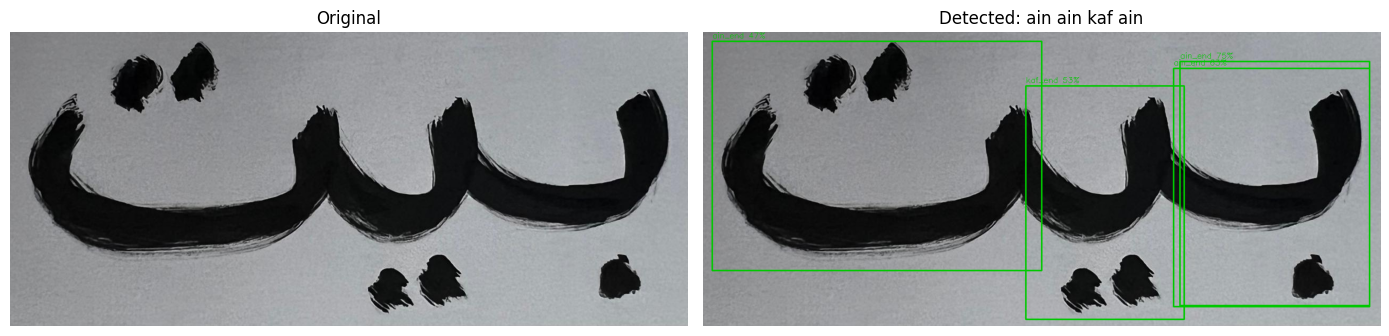

In [37]:
# ── Test on a word image ─────────────────────────────────────
TEST_IMAGE = str(ROOT / 'word_test.png')

word_chars, annotated_img = recognize_word(TEST_IMAGE, conf_threshold=0.1, iou_threshold=0.2)

# Strip form suffix: beh_middle → beh, alif_hamza → alif
word_chars_simple = [str(c).split('_')[0] for c in word_chars]

print(f"\nDetected characters (RTL): {word_chars_simple}")
print(f"Word: {' '.join(word_chars_simple)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(word_chars_simple)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Testing on: 43597dee-WhatsApp_Image_2026-03-23_at_2.21.26_AM_23.jpeg
Detected: ['jeem_end', 'jeem_end', 'alif_hamza']


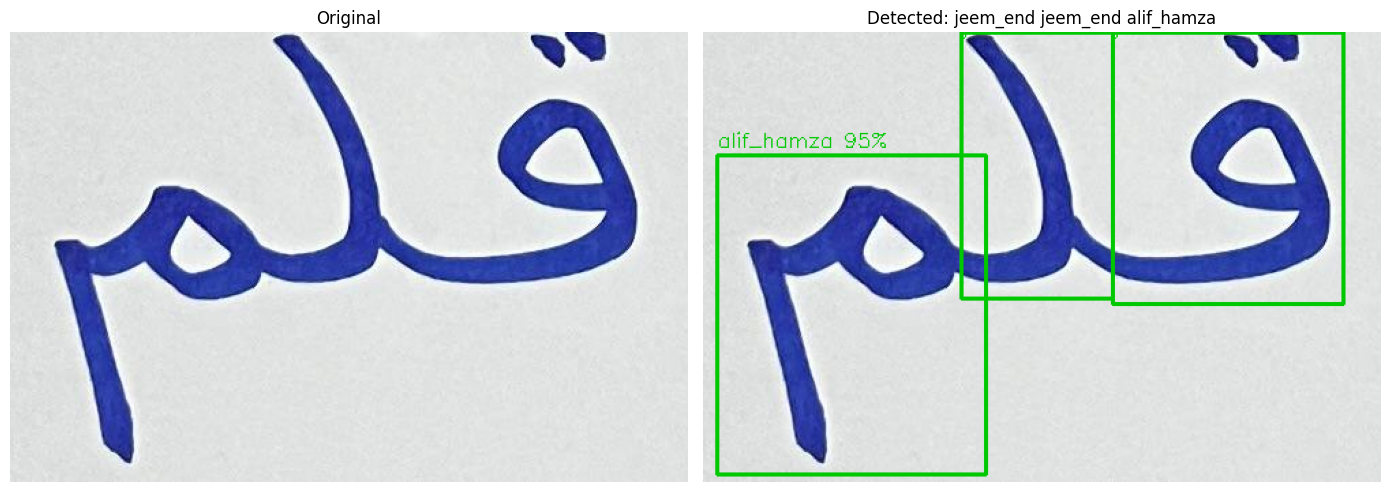

In [38]:
# Pick one of your actual training images
import random
train_img = random.choice(list((MY_DATASET / 'train' / 'images').glob('*.*')))
print(f"Testing on: {train_img.name}")

word_chars, annotated_img = recognize_word(str(train_img), conf_threshold=0.2, iou_threshold=0.3)
print(f"Detected: {word_chars}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(str(train_img)), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(str(c) for c in word_chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()